# 1 - GAIA AGN on-the-fly, MOCs, and _healpix_29

In [2]:
# to-do - use the new show versions method
%pip list | grep -E 'lsdb|nested|hats'
!echo
!which python

hats                              0.8.2
hats-import                       0.8.2
lsdb                              0.8.3.dev6+g98e7fc092         /home/o/olynn/CODE/lsdb
nested-pandas                     0.6.8
Note: you may need to restart the kernel to use updated packages.

/usr/local/share/jupyterlab/venv/bin/python


In [64]:
import os
import logging
import warnings
import lsdb
import pyarrow.parquet as pq
from pathlib import Path
import fsspec
from io import BytesIO

from dask.distributed import Client

In [65]:
# Suppress the port-in-use UserWarning
warnings.filterwarnings("ignore", message="Port 8787 is already in use")

# Raise the log level for distributed so INFO messages are hidden
logging.getLogger("distributed").setLevel(logging.WARNING)

# Make a dask client
client = Client(
    n_workers=4,
    memory_limit="4GB",
)
client

/home/o/olynn/.local/lib/python3.12/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=74, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: proxy/40443/status,
Dashboard: proxy/40443/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35859,Workers: 0
Dashboard: proxy/40443/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40703,Total threads: 1
Dashboard: proxy/36905/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:33701,


In [77]:
# Get dask dashboard link

base_url = os.environ.get('JUPYTERHUB_SERVICE_PREFIX', '')
dashboard_url = f"https://usdf-rsp.slac.stanford.edu{base_url}proxy/8787/status"
print(f"Dask Dashboard: {dashboard_url}")

Dask Dashboard: https://usdf-rsp.slac.stanford.edu/nb/user/olynn/proxy/8787/status


## About GAIA AGN

In [ ]:
# Columns table, link to paper maybe

## Getting the GAIA AGN Catalog

In [9]:
gaia_agn_remote_path = "https://vizcat.cds.unistra.fr/hats/I/358/vagn/"

gaia_agn_remote = lsdb.open_catalog(gaia_agn_remote_path, columns=["_RAJ2000", "_DEJ2000"])

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of I/358/vagn'}>)

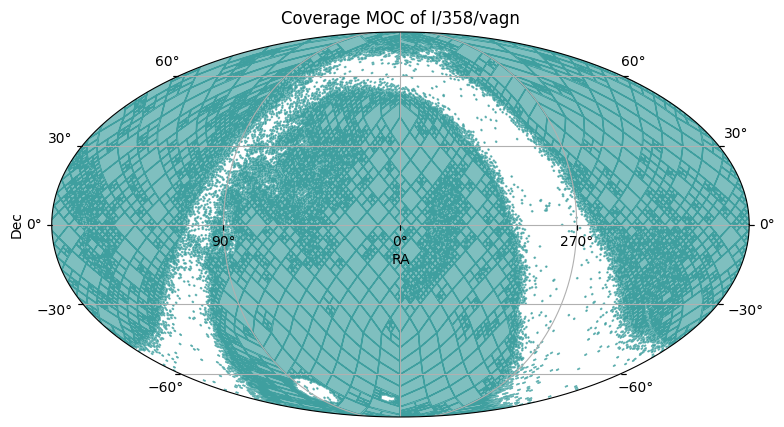

In [11]:
gaia_agn_remote.plot_coverage()

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - I/358/vagn'}>)

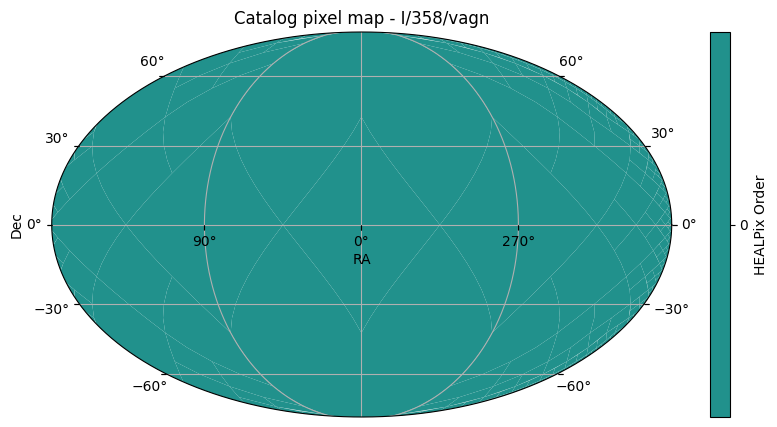

In [14]:
gaia_agn_remote.plot_pixels()

## Save GAIA AGN Locally

We choose to save the catalog locally, as we run into DNS issues otherwise

In [13]:
gaia_agn_remote.write_catalog("gaia_agn/", catalog_name="gaia_agn")

## Load GAIA AGN Local

In [16]:
gaia_agn_local_path = "./gaia_agn"

gaia_agn_local = lsdb.open_catalog(gaia_agn_local_path, columns=["_RAJ2000", "_DEJ2000"])

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of gaia_agn'}>)

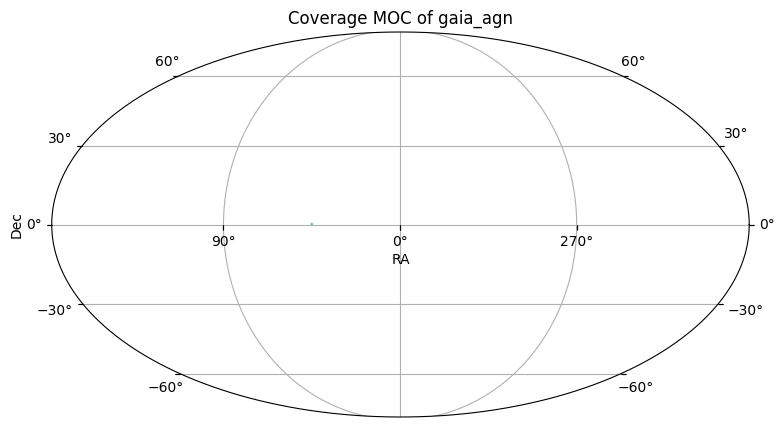

In [17]:
gaia_agn_local.plot_coverage()

## Check it out

Note that it does, in fact, have a tiny bit of coverage at dec ~1 and ra ~45! But, this isn't the full coverage :(

Long story short, this is linked to the missing index column.

In [23]:
!tree {gaia_agn_local_path}

./gaia_agn
├── collection.properties
└── gaia_agn
    ├── dataset
    │   ├── Norder=0
    │   │   └── Dir=0
    │   │       ├── Npix=0.parquet
    │   │       ├── Npix=1.parquet
    │   │       ├── Npix=10.parquet
    │   │       ├── Npix=11.parquet
    │   │       ├── Npix=2.parquet
    │   │       ├── Npix=3.parquet
    │   │       ├── Npix=4.parquet
    │   │       ├── Npix=5.parquet
    │   │       ├── Npix=6.parquet
    │   │       ├── Npix=7.parquet
    │   │       ├── Npix=8.parquet
    │   │       └── Npix=9.parquet
    │   ├── _common_metadata
    │   ├── _metadata
    │   └── data_thumbnail.parquet
    ├── hats.properties
    ├── partition_info.csv
    ├── point_map.fits
    ├── properties
    └── skymap.fits

5 directories, 21 files


In [51]:
file = Path(gaia_agn_local_path, "gaia_agn", "dataset", "_common_metadata")
print(pq.read_table(file))
"_healpix_29" in pq.read_table(file).schema.names

pyarrow.Table
_RAJ2000: double
_DEJ2000: double
----
_RAJ2000: [[]]
_DEJ2000: [[]]


False

In [2]:
# Compared to the remote catalog's common metadata

#url = "https://vizcat.cds.unistra.fr/hats/I/358/vagn/dataset/_common_metadata"
#fs = fsspec.filesystem("https")
#with fs.open(url, "rb") as f:
#    buf = BytesIO(f.read())
#table = pq.read_table(buf)

## Compare this to DP2, which should have _healpix_29

In [36]:
dp2_path = '/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/dia_object_collection'
dp2 = lsdb.open_catalog(dp2_path, columns=["diaObjectId", "ra", "dec", "diaObjectForcedSource"])
dp2

,diaObjectId,ra,dec,diaObjectForcedSource
npartitions=7725,,,,
"Order: 7, Pixel: 68159",int64[pyarrow],double[pyarrow],double[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 4, Pixel: 1065",...,...,...,...
...,...,...,...,...
"Order: 5, Pixel: 12240",...,...,...,...
"Order: 5, Pixel: 12256",...,...,...,...


In [49]:
!tree {dp2_path} | head -m 30

/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/dia_object_collection
├── collection.properties
├── dia_object_lc
│   ├── dataset
│   │   ├── Norder=10
│   │   │   ├── Dir=12050000
│   │   │   │   └── Npix=12055551.parquet
│   │   │   ├── Dir=6990000
│   │   │   │   └── Npix=6997845.parquet
│   │   │   └── Dir=7420000


In [48]:
import pyarrow.compute as pc

file = Path(dp2_path, "dia_object_lc", "dataset", "_common_metadata")
"_healpix_29" in pq.read_table(file).schema.names

True

## Rebuild the index column by converting to dataframe, then back to catalog

In [53]:
df = gaia_agn_local.compute()

In [57]:
df

,_RAJ2000,_DEJ2000
0,45.188575,0.282424
1,45.18948,0.359195
...,...,...
93455,314.710132,-0.327162
93456,315.119522,-0.165171


In [ ]:
"""DataframeCatalogLoader(
    116     dataframe,
    117     ra_column=ra_column,
    118     dec_column=dec_column,
    119     lowest_order=lowest_order,
    120     highest_order=highest_order,
    121     drop_empty_siblings=drop_empty_siblings,
    122     partition_rows=partition_rows,
    123     partition_bytes=partition_bytes,
    124     should_generate_moc=should_generate_moc,
    125     moc_max_order=moc_max_order,
    126     use_pyarrow_types=use_pyarrow_types,
    127     schema=schema,
    128     **kwargs,
    129 )"""

In [67]:
catalog = lsdb.from_dataframe(
    df,
    catalog_name="gaia_agn_from_dataframe",
    catalog_type="object",
    lowest_order=2,
    highest_order=5,
    ra_column="_RAJ2000",
    dec_column="_DEJ2000"
)

# Save it to disk in HATS format
catalog.write_catalog("./gaia_agn_from_dataframe")

/home/o/olynn/.local/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 20.07 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/o/olynn/.local/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 20.07 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/o/olynn/.local/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 20.19 MiB.
This may cause some slowdown.
Consider l

In [68]:
ga_from_df = lsdb.open_catalog("./gaia_agn_from_dataframe")

In [69]:
from_df

,_RAJ2000,_DEJ2000
npartitions=192,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow]
"Order: 2, Pixel: 1",...,...
...,...,...
"Order: 2, Pixel: 190",...,...
"Order: 2, Pixel: 191",...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of gaia_agn_from_dataframe'}>)

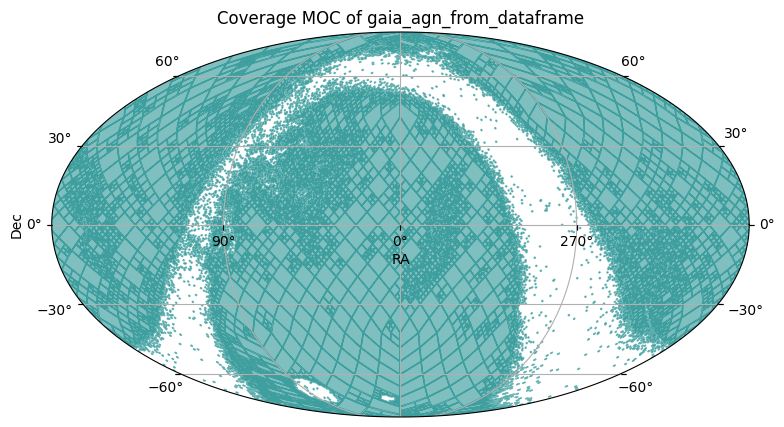

In [70]:
ga_from_df.plot_coverage()

## Get DP2

In [73]:
dp2 = lsdb.open_catalog(
    "/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/dia_object_collection",
    columns=["diaObjectId", "ra", "dec", "diaObjectForcedSource"]
)

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of dia_object_lc'}>)

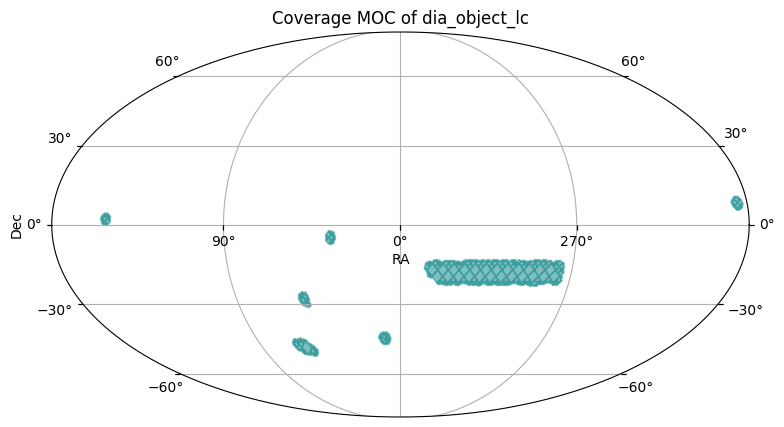

In [74]:
dp2.plot_coverage()

## Set up crossmatch

In [78]:
gaia_agn_x_dp2 = ga_from_df.crossmatch(dp2, output_catalog_name="gaia_agn_x_dp2", suffix_method="overlapping_columns")
gaia_agn_x_dp2

,_RAJ2000,_DEJ2000,diaObjectId,ra,dec,diaObjectForcedSource,_dist_arcsec
npartitions=2122,,,,,,,
"Order: 7, Pixel: 68159",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...",double[pyarrow]
"Order: 4, Pixel: 1065",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12240",...,...,...,...,...,...,...
"Order: 5, Pixel: 12256",...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of gaia_agn_x_dp2'}>)

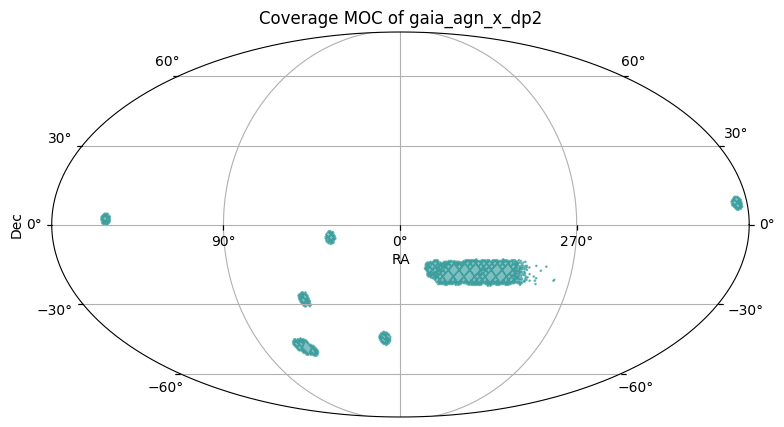

In [79]:
gaia_agn_x_dp2.plot_coverage()

## Run cone-searched crossmatch

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of gaia_agn_x_dp2'}>)

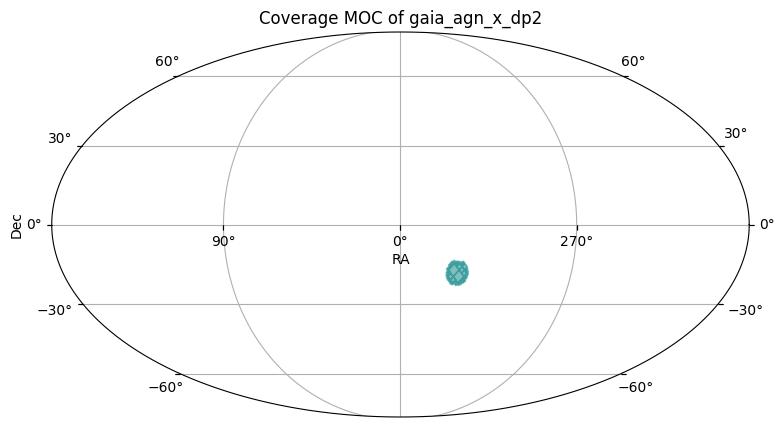

In [82]:
gaia_agn_x_dp2_cone = gaia_agn_x_dp2.cone_search(ra=-30, dec=-18, radius_arcsec=5 * 3600)
gaia_agn_x_dp2_cone.plot_coverage()

In [86]:
gaia_agn_x_dp2_cone.head(5)

_RAJ2000   _DEJ2000        diaObjectId          ra  \
_healpix_29                                                                 
1297776238299427342  335.016091 -17.185087  46849228386861467  335.016085   
1297776496568537328  335.055644 -17.156706  46849228386861282  335.055655   
1297778335516432313  334.922458 -17.135144  46849297106337823  334.922458   
1297778535748996117  334.907377 -17.097634  46849984301105425  334.907402   
1297782394227999239  335.130267 -16.979309  46849846862151743  335.130267   

                           dec  \
_healpix_29                      
1297776238299427342 -17.185083   
1297776496568537328  -17.15669   
1297778335516432313 -17.135135   
1297778535748996117 -17.097624   
1297782394227999239 -16.979307   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
1297776238299427342  [{parentObjectId: 0, coord_ra: 335.016085, coo...   
1297776496568537328  [{parentObjectId: 0, coord_ra: 335.055655, coo...   
1297778335516432313  [{parentObjectId: 0, coord_ra: 334.922458, coo...   
1297778535748996117  [{parentObjectId: 0, coord_ra: 334.907402, coo...   
1297782394227999239  [{parentObjectId: 0, coord_ra: 335.130267, coo...   

                     _dist_arcsec  
_healpix_29                        
1297776238299427342      0.023775  
1297776496568537328      0.067856  
1297778335516432313      0.030118  
1297778535748996117      0.093861  
1297782394227999239      0.008063

In [83]:
#gaia_agn_x_dp2_cone.write_catalog("xmatched_cats", catalog_name="ga_x_dp2_cone")

## Run full crossmatch

In [87]:
gaia_agn_x_dp2.head(5)

_RAJ2000   _DEJ2000        diaObjectId          ra  \
_healpix_29                                                                 
1199082000028818063  342.989184 -19.607069  43696859830550585  342.989192   
1199799084675512657  343.535528 -19.751029  43703456900317185  343.535549   
1199815675876963592  343.918047 -19.548181  43704693850898496  343.918079   
1199835500363950558  343.489634 -19.444504  43697340866887709  343.489828   
1199852887212822005  343.664362 -19.045443  45288128033849399  343.664341   

                           dec  \
_healpix_29                      
1199082000028818063  -19.60707   
1199799084675512657 -19.751035   
1199815675876963592 -19.548171   
1199835500363950558 -19.444423   
1199852887212822005 -19.045427   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
1199082000028818063  [{parentObjectId: 0, coord_ra: 342.989192, coo...   
1199799084675512657  [{parentObjectId: 0, coord_ra: 343.535549, coo...   
1199815675876963592  [{parentObjectId: 0, coord_ra: 343.918079, coo...   
1199835500363950558  [{parentObjectId: 0, coord_ra: 343.489828, coo...   
1199852887212822005  [{parentObjectId: 0, coord_ra: 343.664341, coo...   

                     _dist_arcsec  
_healpix_29                        
1199082000028818063      0.025907  
1199799084675512657      0.074434  
1199815675876963592      0.113474  
1199835500363950558      0.719588  
1199852887212822005      0.091714

In [112]:
gaia_agn_x_dp2.write_catalog("xmatched_cats", catalog_name="ga_x_dp2_full")

/home/o/olynn/CODE/lsdb/src/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
/home/o/olynn/CODE/lsdb/src/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
2026-03-17 14:45:55,107 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-no

## Main friction

1. I really, really wish there was a lsdb.verify_catalog(...) or such

In [ ]:
# In hats, we have hats.verify_catalog(...)

# Interestingly, this was giving an "all good" to our faulty catalog above